# Catalogue de données Géospatiales Humanitaires
## Humanitarian Geo-Catalogue - ISO 19115 | DAMA-DMBOK v2

---

### Pourquoi un catalogue de données ?

Dans les organisations humanitaires, la donnée géospatiale est partout :
cartes de zones d'intervention, localisations de formations sanitaires,
corridors logistiques, données de conflits géoréférencées.

**Le problème : personne ne sait ce qui existe.**

Un analyste à Dakar cherche les limites administratives de la RCA.
Un coordinateur à Genève a déjà ce dataset mais personne ne le sait.
Résultat : duplication de travail, données inconsistantes, décisions
basées sur des informations obsolètes.

**La solution : un catalogue de données standardisé.**

Ce notebook explore le catalogue humanitaire que nous avons construit —
5 datasets documentés selon le standard international **ISO 19115**,
avec métadonnées complètes, classification de sécurité et lineage documenté.

### Ce que vous allez voir

1. **Vue d'ensemble** : les 5 datasets du catalogue
2. **Analyse des métadonnées** : complétude et qualité de la documentation
3. **Répartition par domaine** : qui gère quoi ?
4. **Lineage**d'où :  viennent les données et comment ont-elles été transformées ?
5. **Recommandations** : comment améliorer la gouvernance du catalogue

### À qui s'adresse ce notebook ?

- **Responsables de données** qui veulent structurer leur catalogue
- **Chargés de programme** qui cherchent des datasets existants
- **Équipes IT** qui gèrent l'infrastructure de données
- **Bailleurs** qui veulent vérifier la qualité de la documentation

## Étape 1 : Chargement du catalogue

Nous chargeons les 5 datasets documentés dans le catalogue
et leurs métadonnées ISO 19115 complètes.

Le catalogue couvre les 5 domaines de données humanitaires :
- **DD01** - Données géospatiales de référence
- **DD02** - Données opérationnelles terrain
- **DD03** - Données de santé et épidémiologie
- **DD04** - Données logistiques et chaîne d'approvisionnement
- **DD05** - Données de contexte et sécurité

In [7]:
# ─────────────────────────────────────────────────────────────
# Imports
# ─────────────────────────────────────────────────────────────
import sys
import json
import os
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Configuration graphique
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ─────────────────────────────────────────────────────────────
# Chargement du catalogue
# ─────────────────────────────────────────────────────────────
from catalogue.catalogue import GeoCatalogue
from catalogue.lineage import LineageStore

catalogue = GeoCatalogue(config_path='config/catalogue.yaml')
lineage_store = LineageStore()

records = catalogue.list_records()
df = pd.DataFrame(records)

print("✓ Catalogue chargé avec succès")
print(f"\n  Datasets documentés : {len(records)}")
print(f"  Colonnes metadata   : {len(df.columns)}")
print(f"\n  Colonnes disponibles :")
for col in df.columns:
    non_null = df[col].notna().sum()
    print(f"  • {col:<30} {non_null}/{len(df)} renseignés")

✓ Catalogue chargé avec succès

  Datasets documentés : 5
  Colonnes metadata   : 24

  Colonnes disponibles :
  • record_id                      5/5 renseignés
  • title                          5/5 renseignés
  • abstract                       5/5 renseignés
  • domain                         5/5 renseignés
  • classification                 5/5 renseignés
  • geometry_type                  5/5 renseignés
  • crs                            5/5 renseignés
  • source_organization            5/5 renseignés
  • data_steward                   5/5 renseignés
  • update_frequency               5/5 renseignés
  • format                         5/5 renseignés
  • date_created                   5/5 renseignés
  • date_modified                  5/5 renseignés
  • keywords                       5/5 renseignés
  • topic_category                 5/5 renseignés
  • bounding_box                   5/5 renseignés
  • temporal_extent_start          5/5 renseignés
  • temporal_extent_end            5/5 

## Étape 2 : Vue d'ensemble du catalogue

### Les 5 datasets documentés

Chaque dataset dans ce catalogue représente une couche de données
géospatiales utilisée dans les opérations humanitaires.

La documentation ISO 19115 garantit que chaque dataset est :
- **Identifiable** : titre, abstract, identifiant unique
- **Localisable** : bounding box géographique, CRS
- **Traçable** : source, lineage, date de création
- **Sécurisé** : niveau de classification défini
- **Accessible** : format, URL d'accès, licence

### Pourquoi ISO 19115 ?

C'est le standard international pour les métadonnées géospatiales.
Utilisé par l'ONU, l'UE (directive INSPIRE), l'OCHA et la plupart
des agences de développement. Un catalogue conforme ISO 19115 est
interopérable avec n'importe quel système de gestion de données.

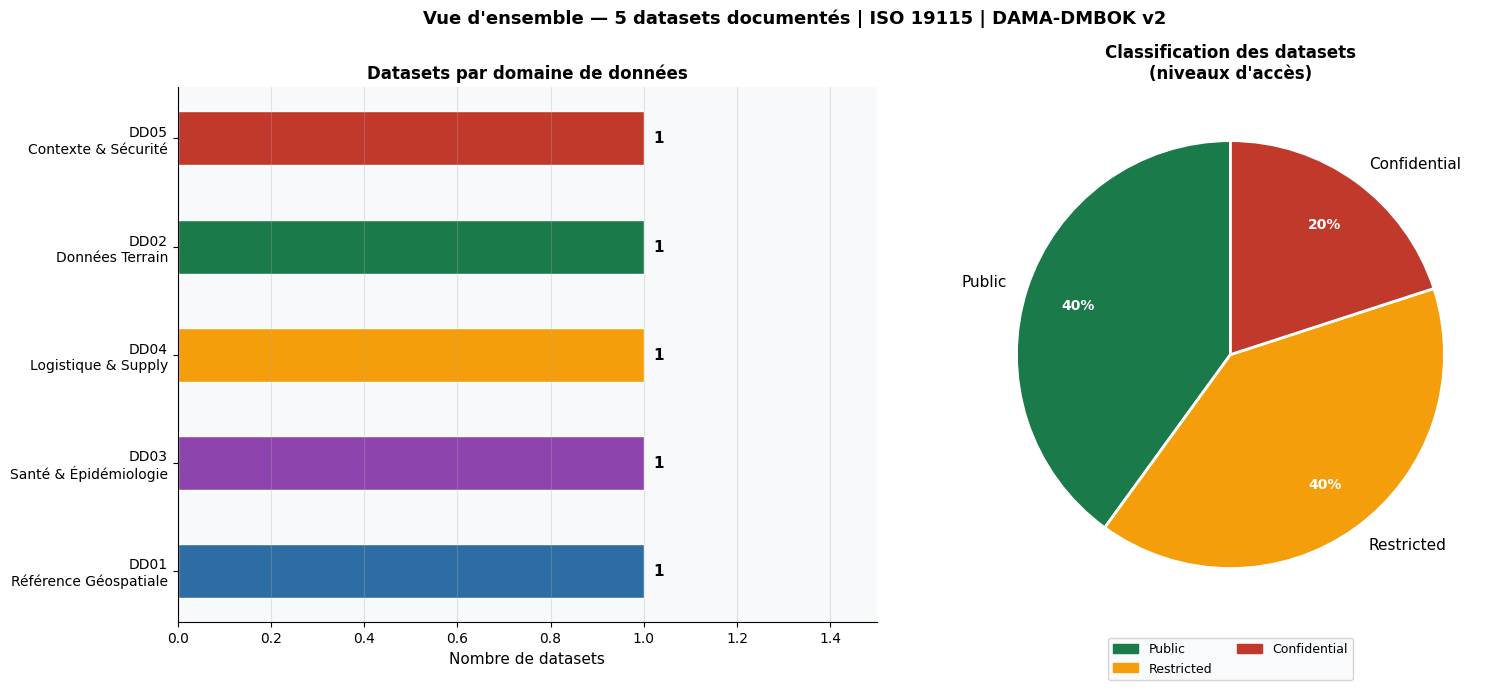


Catalogue — Récapitulatif :
----------------------------------------------------------------------
Titre                                         Domaine         Class.       Format
----------------------------------------------------------------------
Limites administratives RCA — Niveau 1          DD01         Public   GeoPackage
Formations sanitaires — Mauritanie              DD03         Public   GeoPackage
Corridors logistiques — Sahel Ouest             DD04     Restricted      GeoJSON
Zones d'intervention — Programme RCA 2023-2     DD02     Restricted      GeoJSON
Événements de conflit — RCA 2024-2025           DD05   Confidential      GeoJSON
----------------------------------------------------------------------
✓ 5 datasets documentés


In [8]:
# Vue d'ensemble du catalogue
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Graphique 1 : Datasets par domaine ───────────────────────
ax1 = axes[0]

DOMAIN_LABELS = {
    'DD01': 'Référence Géospatiale',
    'DD02': 'Données Terrain',
    'DD03': 'Santé & Épidémiologie',
    'DD04': 'Logistique & Supply',
    'DD05': 'Contexte & Sécurité'
}

domain_colors = {
    'DD01': '#2E6DA4',
    'DD02': '#1a7a4a',
    'DD03': '#8e44ad',
    'DD04': '#f59e0b',
    'DD05': '#c0392b'
}

domain_counts = df['domain'].value_counts()
colors = [domain_colors.get(d, '#666') for d in domain_counts.index]
labels = [f"{d}\n{DOMAIN_LABELS.get(d, d)}" for d in domain_counts.index]

bars = ax1.barh(labels, domain_counts.values,
                color=colors, edgecolor='white', height=0.5)

for bar, val in zip(bars, domain_counts.values):
    ax1.text(bar.get_width() + 0.02,
             bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=11, fontweight='bold')

ax1.set_xlabel('Nombre de datasets', fontsize=11)
ax1.set_title('Datasets par domaine de données', fontsize=12, fontweight='bold')
ax1.set_xlim(0, max(domain_counts.values) + 0.5)
ax1.grid(axis='x', alpha=0.3)

# ── Graphique 2 : Classification des datasets ────────────────
ax2 = axes[1]

CLASS_COLORS = {
    'Public':       '#1a7a4a',
    'Restricted':   '#f59e0b',
    'Confidential': '#c0392b',
    'Sensitive':    '#6c0f0f'
}

class_counts = df['classification'].value_counts()
colors_class = [CLASS_COLORS.get(c, '#666') for c in class_counts.index]

wedges, texts, autotexts = ax2.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.0f%%',
    colors=colors_class,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.75
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax2.set_title('Classification des datasets\n(niveaux d\'accès)',
              fontsize=12, fontweight='bold')

# Légende classification
legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[c], label=c)
    for c in ['Public', 'Restricted', 'Confidential', 'Sensitive']
    if c in class_counts.index
]
ax2.legend(handles=legend_patches, fontsize=9,
           loc='lower center', bbox_to_anchor=(0.5, -0.12),
           ncol=2)

plt.suptitle(
    f'Vue d\'ensemble — {len(records)} datasets documentés | '
    f'ISO 19115 | DAMA-DMBOK v2',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('notebooks/catalogue_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Tableau récapitulatif
print("\nCatalogue — Récapitulatif :")
print("-" * 70)
print(f"{'Titre':<45} {'Domaine':>6} {'Class.':>14} {'Format':>12}")
print("-" * 70)
for _, row in df.iterrows():
    title = str(row['title'])[:43]
    print(f"{title:<45} {row['domain']:>6} "
          f"{row['classification']:>14} {row.get('format', 'N/A'):>12}")
print("-" * 70)
print(f"✓ {len(records)} datasets documentés")

In [9]:
import os
os.makedirs('notebooks', exist_ok=True)
print("Dossier notebooks créé")

Dossier notebooks créé


## Étape 3 : Analyse de la complétude des métadonnées

### Pourquoi mesurer la complétude ?

Un catalogue incomplet est inutile. Si les métadonnées manquent,
le dataset devient non découvrable, comme un livre sans titre
ni résumé dans une bibliothèque.

### Les champs ISO 19115 obligatoires

La norme ISO 19115 définit des champs **obligatoires** et **optionnels**.
Dans notre catalogue, nous mesurons le taux de remplissage de chaque champ
pour identifier les lacunes de documentation.

**Règle d'or de la gouvernance des données :**
Un dataset sans métadonnées complètes ne doit pas être promu en production.
C'est exactement le principe que nous appliquons dans le
`geodata-quality-pipeline`: qualité des données ET qualité de leur documentation.

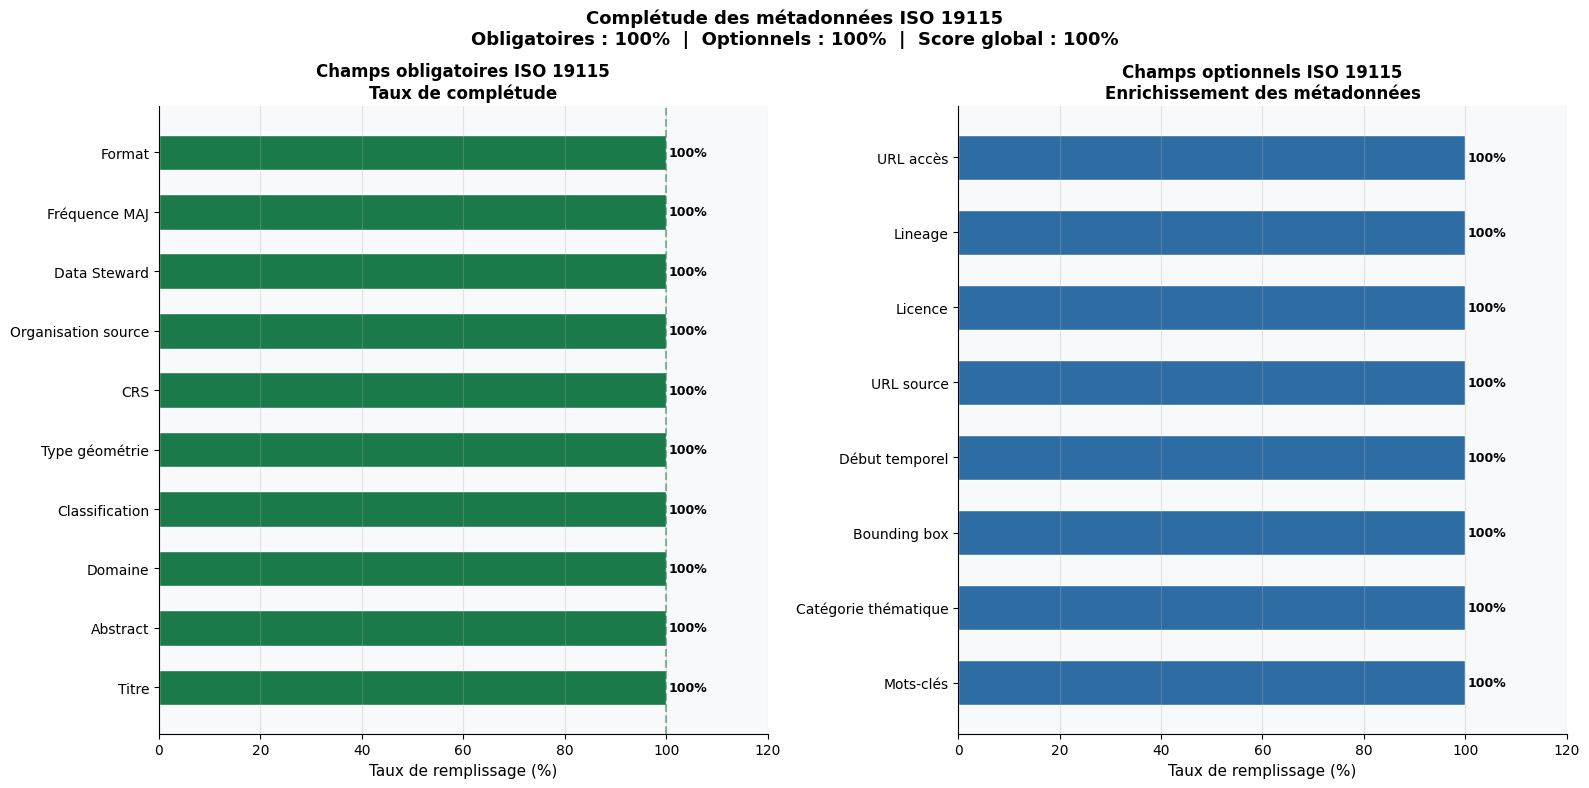

✓ Graphique sauvegardé

Score de complétude :
  Champs obligatoires : 100%
  Champs optionnels   : 100%
  Score global        : 100%


In [10]:
# Analyse de la complétude des métadonnées
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Graphique 1 : Taux de remplissage par champ ───────────────
ax1 = axes[0]

# Champs ISO 19115 à vérifier
mandatory_fields = [
    'title', 'abstract', 'domain', 'classification',
    'geometry_type', 'crs', 'source_organization',
    'data_steward', 'update_frequency', 'format'
]

optional_fields = [
    'keywords', 'topic_category', 'bounding_box',
    'temporal_extent_start', 'source_url', 'licence',
    'lineage_description', 'access_url'
]

all_fields = mandatory_fields + optional_fields
field_labels = {
    'title': 'Titre', 'abstract': 'Abstract',
    'domain': 'Domaine', 'classification': 'Classification',
    'geometry_type': 'Type géométrie', 'crs': 'CRS',
    'source_organization': 'Organisation source',
    'data_steward': 'Data Steward',
    'update_frequency': 'Fréquence MAJ', 'format': 'Format',
    'keywords': 'Mots-clés', 'topic_category': 'Catégorie thématique',
    'bounding_box': 'Bounding box',
    'temporal_extent_start': 'Début temporel',
    'source_url': 'URL source', 'licence': 'Licence',
    'lineage_description': 'Lineage', 'access_url': 'URL accès'
}

completeness = {}
for field in all_fields:
    if field in df.columns:
        filled = df[field].apply(
            lambda x: bool(x) and x != {} and x != []
        ).sum()
        completeness[field] = (filled / len(df)) * 100
    else:
        completeness[field] = 0

# Séparation obligatoires / optionnels
mandatory_completeness = {f: completeness[f] for f in mandatory_fields}
optional_completeness = {f: completeness[f] for f in optional_fields}

labels_m = [field_labels.get(f, f) for f in mandatory_fields]
values_m = list(mandatory_completeness.values())
colors_m = ['#1a7a4a' if v == 100 else '#f59e0b' if v >= 50 else '#c0392b'
            for v in values_m]

bars = ax1.barh(labels_m, values_m, color=colors_m,
                edgecolor='white', height=0.6)

for bar, val in zip(bars, values_m):
    ax1.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f'{val:.0f}%', va='center', fontsize=9, fontweight='bold')

ax1.axvline(x=100, color='#1a7a4a', linestyle='--', alpha=0.5)
ax1.set_xlim(0, 120)
ax1.set_xlabel('Taux de remplissage (%)', fontsize=11)
ax1.set_title('Champs obligatoires ISO 19115\nTaux de complétude',
              fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# ── Graphique 2 : Champs optionnels ──────────────────────────
ax2 = axes[1]

labels_o = [field_labels.get(f, f) for f in optional_fields]
values_o = list(optional_completeness.values())
colors_o = ['#2E6DA4' if v == 100 else '#85B7EB' if v >= 50 else '#D9E8F5'
            for v in values_o]

bars2 = ax2.barh(labels_o, values_o, color=colors_o,
                 edgecolor='white', height=0.6)

for bar, val in zip(bars2, values_o):
    ax2.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f'{val:.0f}%', va='center', fontsize=9, fontweight='bold')

ax2.set_xlim(0, 120)
ax2.set_xlabel('Taux de remplissage (%)', fontsize=11)
ax2.set_title('Champs optionnels ISO 19115\nEnrichissement des métadonnées',
              fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Scores globaux
mandatory_score = np.mean(values_m)
optional_score = np.mean(values_o)

plt.suptitle(
    f'Complétude des métadonnées ISO 19115\n'
    f'Obligatoires : {mandatory_score:.0f}%  |  '
    f'Optionnels : {optional_score:.0f}%  |  '
    f'Score global : {(mandatory_score + optional_score)/2:.0f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('notebooks/metadata_completeness.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Graphique sauvegardé")
print(f"\nScore de complétude :")
print(f"  Champs obligatoires : {mandatory_score:.0f}%")
print(f"  Champs optionnels   : {optional_score:.0f}%")
print(f"  Score global        : {(mandatory_score + optional_score)/2:.0f}%")

## Étape 4 : Traçabilité des données (Lineage)

### Qu'est-ce que le lineage ?

Le **lineage** (ou traçabilité) documente le parcours complet d'un dataset :
d'où vient-il, comment a-t-il été transformé, qui l'a validé,
et quand a-t-il été publié.

### Pourquoi c'est critique dans le contexte humanitaire ?

Imaginez une carte de zones d'intervention utilisée pour planifier
une distribution alimentaire. Si les limites géographiques sont incorrectes,
des milliers de bénéficiaires peuvent être exclus.

Le lineage permet de répondre à ces questions vitales :
- **D'où vient ce dataset ?** → Source officielle ou terrain ?
- **Quand a-t-il été mis à jour ?** → Est-il encore valide ?
- **Qui l'a validé ?** → Le Data Steward a-t-il approuvé ?
- **A-t-il été transformé ?** → Les projections sont-elles correctes ?

### Les 4 étapes du lineage documenté

Dans notre catalogue, chaque dataset passe par 4 étapes documentées :

| Étape | Description |
|-------|-------------|
| **Acquisition** | Téléchargement depuis la source (HDX, OSM, ACLED) |
| **Transformation** | Conversion de format, reprojection CRS |
| **Validation** | Checks qualité automatisés (geodata-quality-pipeline) |
| **Publication** | Mise en ligne dans le catalogue avec métadonnées |

✓ Lineage chargé : 5 datasets tracés


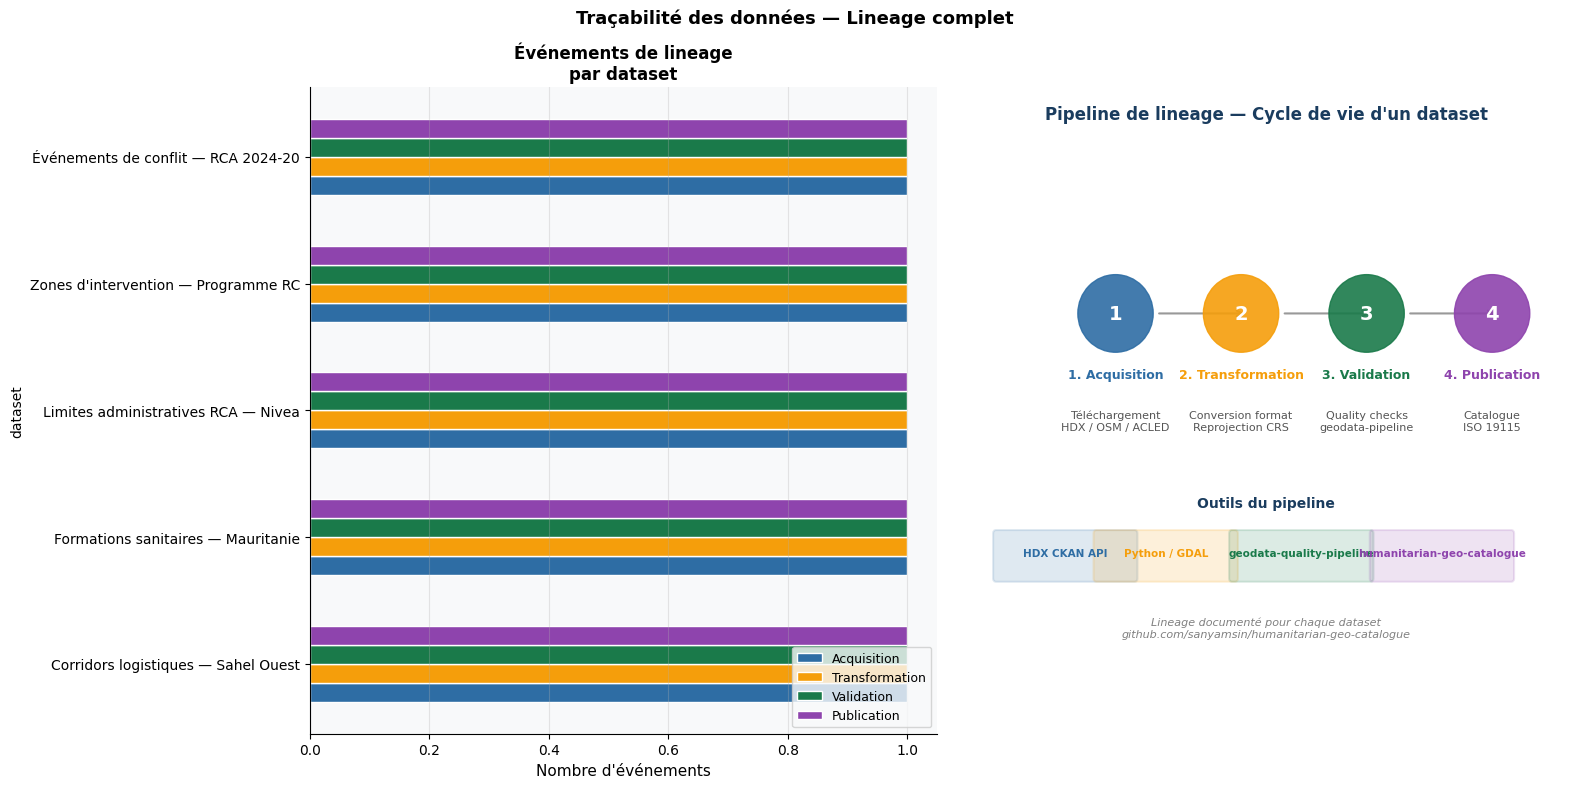

✓ Graphique sauvegardé


In [11]:
# Analyse du lineage des datasets
lineage_records = lineage_store.list_all()

print(f"✓ Lineage chargé : {len(lineage_records)} datasets tracés")

# ── Visualisation du lineage ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Graphique 1 : Étapes par dataset
ax1 = axes[0]

EVENT_COLORS = {
    'acquisition':    '#2E6DA4',
    'transformation': '#f59e0b',
    'validation':     '#1a7a4a',
    'publication':    '#8e44ad'
}

EVENT_LABELS = {
    'acquisition':    'Acquisition',
    'transformation': 'Transformation',
    'validation':     'Validation',
    'publication':    'Publication'
}

lineage_data = []
for record in lineage_records:
    title = record['dataset_title'][:35]
    for event in record['events']:
        lineage_data.append({
            'dataset': title,
            'event_type': event['event_type'],
            'tool': event.get('tool_used', 'N/A'),
            'performed_by': event.get('performed_by', 'N/A')
        })

df_lineage = pd.DataFrame(lineage_data)

if len(df_lineage) > 0:
    event_counts = df_lineage.groupby(
        ['dataset', 'event_type']
    ).size().unstack(fill_value=0)

    event_types = ['acquisition', 'transformation', 'validation', 'publication']
    existing_types = [e for e in event_types if e in event_counts.columns]
    colors_events = [EVENT_COLORS[e] for e in existing_types]

    event_counts[existing_types].plot(
        kind='barh', ax=ax1,
        color=colors_events,
        edgecolor='white', width=0.6
    )

    ax1.set_xlabel('Nombre d\'événements', fontsize=11)
    ax1.set_title('Événements de lineage\npar dataset', fontsize=12, fontweight='bold')
    ax1.legend([EVENT_LABELS.get(e, e) for e in existing_types],
               fontsize=9, loc='lower right')
    ax1.grid(axis='x', alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'Lineage non disponible',
             ha='center', va='center', fontsize=12, color='gray')
    ax1.axis('off')

# Graphique 2 : Pipeline lineage visuel
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')

ax2.text(5, 9.5, 'Pipeline de lineage — Cycle de vie d\'un dataset',
         ha='center', fontsize=12, fontweight='bold', color='#1A3C5E')

steps = [
    ('1. Acquisition', 'Téléchargement\nHDX / OSM / ACLED', '#2E6DA4', 2.0),
    ('2. Transformation', 'Conversion format\nReprojection CRS', '#f59e0b', 4.5),
    ('3. Validation', 'Quality checks\ngeodata-pipeline', '#1a7a4a', 7.0),
    ('4. Publication', 'Catalogue\nISO 19115', '#8e44ad', 9.5),
]

for title, desc, color, x in steps:
    # Cercle
    circle = plt.Circle((x/10*8 + 1, 6.5), 0.6,
                         color=color, alpha=0.9, zorder=5)
    ax2.add_patch(circle)

    # Numéro
    ax2.text(x/10*8 + 1, 6.5, title[0],
             ha='center', va='center', fontsize=14,
             fontweight='bold', color='white', zorder=6)

    # Titre
    ax2.text(x/10*8 + 1, 5.5, title,
             ha='center', fontsize=9, fontweight='bold', color=color)

    # Description
    ax2.text(x/10*8 + 1, 4.7, desc,
             ha='center', fontsize=8, color='#555')

    # Flèche vers la prochaine étape
    if x < 9.5:
        ax2.annotate('',
                     xy=((x/10*8 + 1 + 2.1)/1, 6.5),
                     xytext=(x/10*8 + 1.65, 6.5),
                     arrowprops=dict(arrowstyle='->', color='#999', lw=1.5))

# Outils utilisés
ax2.text(5, 3.5, 'Outils du pipeline',
         ha='center', fontsize=10, fontweight='bold', color='#1A3C5E')

tools = [
    ('HDX CKAN API', '#2E6DA4', 1.5),
    ('Python / GDAL', '#f59e0b', 3.5),
    ('geodata-quality-pipeline', '#1a7a4a', 6.2),
    ('humanitarian-geo-catalogue', '#8e44ad', 9.0),
]

for tool, color, x in tools:
    rect = mpatches.FancyBboxPatch(
        (x/10*8 - 0.5, 2.4), 2.2, 0.7,
        boxstyle="round,pad=0.05",
        facecolor=color, alpha=0.15,
        edgecolor=color, linewidth=1.5
    )
    ax2.add_patch(rect)
    ax2.text(x/10*8 + 0.6, 2.75, tool,
             ha='center', fontsize=7.5, color=color, fontweight='bold')

ax2.text(5, 1.5,
         'Lineage documenté pour chaque dataset\n'
         'github.com/sanyamsin/humanitarian-geo-catalogue',
         ha='center', fontsize=8, color='gray', style='italic')

plt.suptitle('Traçabilité des données — Lineage complet',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/lineage_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé")

## Étape 5 : Recommandations pour améliorer le catalogue

### Comment passer d'un bon catalogue à un excellent catalogue ?

Notre catalogue actuel est bien structuré en 5 datasets documentés,
métadonnées ISO 19115 complètes, lineage tracé pour chaque dataset.

Mais un catalogue de données humanitaires à l'échelle d'une organisation
comme LuxDev, MSF ou l'OCHA gère des centaines de datasets.

### Les 3 axes d'amélioration prioritaires

**Axe 1 - Automatisation de l'ingestion**
Connecter le catalogue directement aux sources de données :
HDX, OSM, ACLED, ReliefWeb. Chaque nouveau dataset est
automatiquement documenté à l'ingestion.

**Axe 2 - Fédération avec d'autres catalogues**
Connecter notre catalogue au catalogue HDX de l'OCHA et
au GeoNetwork de l'UE. Un dataset documenté une fois
devient visible dans tous les systèmes.

**Axe 3 - Gouvernance active**
Mettre en place les revues trimestrielles du catalogue :
- Datasets obsolètes → archivés
- Datasets incomplets → complétés par les Data Stewards
- Nouveaux datasets → documentés avant publication

### La règle des 3 "Pas de données sans métadonnées"

1. **Pas de dataset sans titre et abstract** → non découvrable
2. **Pas de dataset sans Data Steward** → non responsable
3. **Pas de dataset sans lineage** → non traçable

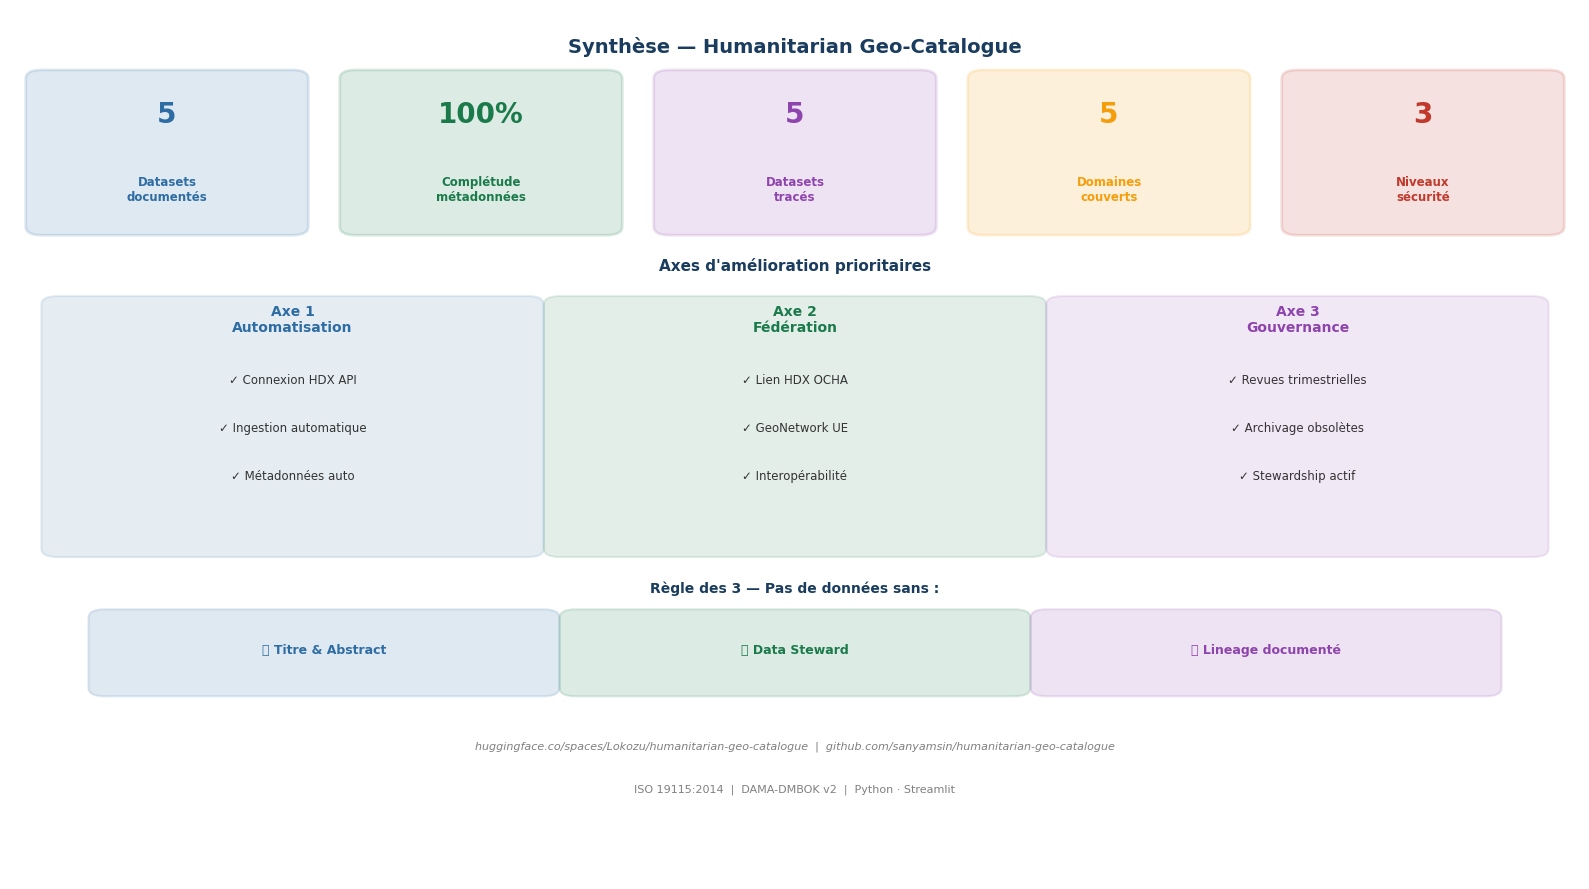

✓ Synthèse sauvegardée

  NOTEBOOK TERMINÉ ✓
  5 datasets documentés — ISO 19115
  Complétude métadonnées : 100%
  Lineage tracé : 5 datasets


In [12]:
# Synthèse finale et recommandations
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Titre
ax.text(5, 9.5, 'Synthèse — Humanitarian Geo-Catalogue',
        ha='center', fontsize=14, fontweight='bold', color='#1A3C5E')

# KPIs
kpis = [
    (str(len(records)), 'Datasets\ndocumentés', '#2E6DA4'),
    (f'{mandatory_score:.0f}%', 'Complétude\nmétadonnées', '#1a7a4a'),
    (str(len(lineage_records)), 'Datasets\ntracés', '#8e44ad'),
    (str(df['domain'].nunique()), 'Domaines\ncouverts', '#f59e0b'),
    (str(df['classification'].nunique()), 'Niveaux\nsécurité', '#c0392b'),
]

for i, (val, label, color) in enumerate(kpis):
    x = 1.0 + i * 2.0
    rect = mpatches.FancyBboxPatch(
        (x - 0.8, 7.5), 1.6, 1.7,
        boxstyle="round,pad=0.1",
        facecolor=color, alpha=0.15,
        edgecolor=color, linewidth=2
    )
    ax.add_patch(rect)
    ax.text(x, 8.7, val, ha='center', fontsize=20,
            fontweight='bold', color=color)
    ax.text(x, 7.8, label, ha='center', fontsize=8.5,
            color=color, fontweight='bold')

# Axes d'amélioration
ax.text(5, 7.0, 'Axes d\'amélioration prioritaires',
        ha='center', fontsize=11, fontweight='bold', color='#1A3C5E')

axes_data = [
    ('Axe 1\nAutomatisation', 
     ['Connexion HDX API', 'Ingestion automatique', 'Métadonnées auto'],
     '#2E6DA4', 1.8),
    ('Axe 2\nFédération',
     ['Lien HDX OCHA', 'GeoNetwork UE', 'Interopérabilité'],
     '#1a7a4a', 5.0),
    ('Axe 3\nGouvernance',
     ['Revues trimestrielles', 'Archivage obsolètes', 'Stewardship actif'],
     '#8e44ad', 8.2),
]

for title, actions, color, x in axes_data:
    rect = mpatches.FancyBboxPatch(
        (x - 1.5, 3.8), 3.0, 2.8,
        boxstyle="round,pad=0.1",
        facecolor=color, alpha=0.12,
        edgecolor=color, linewidth=1.5
    )
    ax.add_patch(rect)

    ax.text(x, 6.3, title, ha='center', fontsize=10,
            fontweight='bold', color=color)

    for j, action in enumerate(actions):
        ax.text(x, 5.7 - j*0.55, f'✓ {action}',
                ha='center', fontsize=8.5, color='#333')

# Règle des 3
ax.text(5, 3.3, 'Règle des 3 — Pas de données sans :',
        ha='center', fontsize=10, fontweight='bold', color='#1A3C5E')

regles = [
    ('Titre & Abstract', '#2E6DA4', 2.0),
    ('Data Steward', '#1a7a4a', 5.0),
    ('Lineage documenté', '#8e44ad', 8.0),
]

for label, color, x in regles:
    rect = mpatches.FancyBboxPatch(
        (x - 1.4, 2.2), 2.8, 0.8,
        boxstyle="round,pad=0.1",
        facecolor=color, alpha=0.15,
        edgecolor=color, linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x, 2.6, f'📋 {label}',
            ha='center', fontsize=9, fontweight='bold', color=color)

ax.text(5, 1.5,
        'huggingface.co/spaces/Lokozu/humanitarian-geo-catalogue  |  '
        'github.com/sanyamsin/humanitarian-geo-catalogue',
        ha='center', fontsize=8, color='gray', style='italic')

ax.text(5, 1.0,
        'ISO 19115:2014  |  DAMA-DMBOK v2  |  Python · Streamlit',
        ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('notebooks/synthese_catalogue.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Synthèse sauvegardée")
print(f"\n{'='*55}")
print(f"  NOTEBOOK TERMINÉ ✓")
print(f"  {len(records)} datasets documentés — ISO 19115")
print(f"  Complétude métadonnées : {mandatory_score:.0f}%")
print(f"  Lineage tracé : {len(lineage_records)} datasets")
print(f"{'='*55}")